<b>Group Number:</b>
<br><b>Name Group Member 1:</b>
<br><b>u-Kürzel Group Member 1:</b>
<br><b>Name Group Member 2:</b>
<br><b>u-Kürzel Group Member 2:</b>

# Unit 1: Introduction & Exploratory Data Analysis (EDA)

## Introduction

Welcome to the LAMA course! This first unit focuses on getting acquainted with a tabular dataset and performing **Exploratory Data Analysis (EDA)**. EDA is a critical first step in any machine learning project. It involves investigating the dataset to understand its main characteristics, discover patterns, spot anomalies, check assumptions, and identify potential issues *before* diving into modeling.

We will be using the **Bank Marketing dataset** for this unit. The goal associated with this dataset is typically to predict whether a client will subscribe to a term deposit (variable 'y').

In this unit, we will:
1.  Load the data using the **Fireducks** library, which provides a Pandas-like interface.
2.  Perform initial data inspection to understand its structure and types.
3.  Calculate descriptive statistics for numerical and categorical features.
4.  Analyze the target variable distribution, paying attention to class balance.
5.  Explore correlations between numerical features.
6.  Create initial visualizations to understand feature distributions.

In [2]:
import pandas as pd  # https://fireducks-dev.github.io/docs/user-guide/04-compatibility/ ||| https://pandas.pydata.org/docs/ <- This contains the API methods
import numpy as np # https://numpy.org/doc/2.1/
import matplotlib.pyplot as plt # https://matplotlib.org/stable/users/index.html
import seaborn as sns #https://seaborn.pydata.org/
from typing import List, Tuple  # For potential type hints later
from IPython.display import display # For displaying DataFrames in Jupyter notebooks (it's weird, and sometimes unnecessary)

# Style settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 50)

## 1.1 Loading Data with Fireducks

The first step is always to load the data into our environment. We'll use `fireducks.pandas`, which mirrors the popular `pandas` library's API. This allows us to use familiar commands while potentially benefiting from backend optimisations (though our focus here is the API).

**Understanding CSV Files**

CSV stands for Comma-Separated Values. It's a very common plain text file format used to store tabular data (data organised in rows and columns, like a spreadsheet or database table).

*   **Structure:** Each line in the file typically represents one row of data. Within each row, values (or fields) are separated by a specific character, called a delimiter. While the comma (`,`) is the most common delimiter (hence the name), other characters like semicolons (`;`), tabs (`\t`), or pipes (`|`) are also used. Sometimes, values containing the delimiter character itself are enclosed in quotation marks (`"`).
*   **Why so common?** CSV files are popular because:
    *   **Simplicity:** They are easy to create and read, both for humans (using a text editor) and programs.
    *   **Compatibility:** Almost all spreadsheet programs (like Excel, Google Sheets), databases, and data analysis tools (like Pandas, R) can easily import and export data in CSV format. This makes it a universal format for data exchange.
    *   **Lightweight:** Being plain text, they don't contain complex formatting like fonts or colours, making the file sizes relatively small compared to formats like Excel's `.xlsx`.

Our dataset is stored in `bank.csv`. We need to load it into a DataFrame.

<div class="alert alert-block alert-success">
<b>Task 1.1: Loading in data (0.5pt)</b> 
<ul>
    <li>Load in the dataset from the provided filepath, considering its choice of delimiter/structure(as per the definition above).
</ul>
</div>

In [3]:
filename: str = "data/bank.csv"
bank_df: pd.DataFrame = None
### STUDENT CODE HERE (0.5pt)
bank_df = pd.read_csv(filename, delimiter=';')

### STUDENT CODE until HERE
if bank_df is not None:
    print("DataFrame loaded successfully.")
else:
    print("Failed to load DataFrame.")

DataFrame loaded successfully.


## 1.2 Initial Data Inspection



Now that the data is loaded into a DataFrame called `bank_df`, let's get a basic understanding of its contents. We want to know:
- How many rows (samples) and columns (features) are there?
- What are the names and data types of the columns?
- Are there any missing values?
- What do the first and last few rows look like?

<div class="alert alert-block alert-info">
    <b>Hint:</b> The dataset originates from the UCI Machine Learning Repository. If the meaning of a specific feature (column name) is unclear, you can find detailed descriptions here:
    <a href="https://archive.ics.uci.edu/dataset/222/bank+marketing" target="_blank">https://archive.ics.uci.edu/dataset/222/bank+marketing</a>
</div>

<div class="alert alert-block alert-success">
<b>Task 1.2: Basic DataFrame Inspection (2 pts)</b>

<ul>
    <li> Use the appropriate DataFrame methods to display:
        <ol>
            <li>The first 7 rows.</li>
            <li>The last 3 rows.</li>
            <li>A concise summary including column data types and non-null counts.</li>
            <li>The total number of rows and columns (shape).</li>
            <li>The count of missing values (NaN) per column.</li>
            <li>A list of all column names.</li>
        </ol>
    </li>
</ul>
</div>

<div class="alert alert-block alert-info">
    <b>Styling Hint:</b> For a cleaner, more readable table-like output of DataFrames, it's recommended to use the <code>display()</code> function. While <code>print()</code> works, <code>display(your_dataframe_expression)</code> provides better formatting that is ideal for exploration. For example, replace <code>print(df)</code> with <code>display(df)</code> where <i>df</i> is your DataFrame or the result of a DataFrame operation.
</div>

In [4]:
print("--- Basic Data Inspection ---")

# 1. Display the first 7 rows
print("\nFirst 7 rows:")
### STUDENT CODE HERE (0.5 pt)
display(bank_df[0:7])


### STUDENT CODE until HERE 

# 2. Display the last 3 rows
print("\nLast 3 rows:")
### STUDENT CODE HERE (0.5 pt) 
length=bank_df.shape[0]
display(bank_df[length-3:length])

### STUDENT CODE until HERE 

# 3. Get basic information (dtypes, non-null counts)
print("\nDataFrame basic info:")
### STUDENT CODE HERE (0.5 pt) 
display(bank_df.info())


### STUDENT CODE until HERE 

# 4. Get the dimensions of the DataFrame (rows, columns)
print("\nDataFrame dimensions (rows, columns):")
### STUDENT CODE HERE (0.25 pt) 
display(bank_df.shape)

### STUDENT CODE until HERE 

# 5. Check for missing values (NaN) per column
print("\nMissing values (NaN) per column:")
### STUDENT CODE HERE (0.25 pt) 
display(bank_df.isna().sum())

### STUDENT CODE until HERE 

# 6. List all column names
# (Already implicitly part of the third look-up
print("\nColumn names:")
### STUDENT CODE HERE (0 pt) 
display(bank_df.columns)

### STUDENT CODE until HERE 

--- Basic Data Inspection ---

First 7 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no



Last 3 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no
4520,44,entrepreneur,single,tertiary,no,1136,yes,yes,cellular,3,apr,345,2,249,7,other,no



DataFrame basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


...

(4521, 17)


Missing values (NaN) per column:


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


Column names:


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

## 1.3 Descriptive Statistics

Let's dive deeper by calculating summary statistics. This helps us understand the central tendency, dispersion, and distribution shape of numerical features, and the frequency of categories for categorical features.

- For **numerical** columns (`age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`), we look at count, mean, standard deviation, min, max, and quartiles (25th, 50th/median, 75th).
- For **categorical** columns (represented as 'object' type, like `job`, `marital`, `education`), we look at count, number of unique categories, the most frequent category (top), and its frequency.

<div class="alert alert-block alert-success">
<b>Task 1.3: Summary Statistics (1.5 pts)</b>

<ul>
    <li> Calculate and display summary statistics for:
        <ol>
            <li>The numerical columns in <i>bank_df</i>.</li>
            <li>The categorical (object type) columns in <i>bank_df</i>.</li>
        </ol>
    </li>
    <li><i>Hint: The <code>.describe()</code> method can be used for both by specifying the <b>include</b> parameter.</i></li>
</ul>
</div>

In [5]:
print("--- Descriptive Statistics ---")

# 1. Summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
pd.set_option('display.float_format', '{:.2f}'.format) # Round floats to 2 decimal places for clearer output
### STUDENT CODE HERE (0.75 pt) 
display(bank_df.describe())

### STUDENT CODE until HERE

# 2. Summary statistics for categorical (object) columns
print("\nSummary statistics for categorical columns:")
### STUDENT CODE HERE (0.75 pt) 
display(bank_df.describe(include =[object]))

### STUDENT CODE until HERE 

--- Descriptive Statistics ---

Summary statistics for numerical columns:


,age,balance,day,duration,campaign,pdays,previous
count,4521.00,4521.00,4521.00,4521.00,4521.00,4521.00,4521.00
mean,41.17,1422.66,15.92,263.96,2.79,39.77,0.54
std,10.58,3009.64,8.25,259.86,3.11,100.12,1.69
min,19.00,-3313.00,1.00,4.00,1.00,-1.00,0.00
25%,33.00,69.00,9.00,104.00,1.00,-1.00,0.00
50%,39.00,444.00,16.00,185.00,2.00,-1.00,0.00
75%,49.00,1480.00,21.00,329.00,3.00,-1.00,0.00
max,87.00,71188.00,31.00,3025.00,50.00,871.00,25.00



Summary statistics for categorical columns:


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


## 1.4 Target Variable Analysis

The goal of this dataset is usually to predict the column `y`, which indicates whether a client subscribed to a term deposit ('yes' or 'no'). Understanding the distribution of this target variable is crucial, especially for classification tasks. An imbalanced dataset (where one class is much more frequent than the other) can significantly impact model training and evaluation.

<div class="alert alert-block alert-success">
<b>Task 1.4: Target Variable Distribution (1.5 pts)</b>

<ul>
    <li> Analyze the distribution of the target column 'y'.
        <ol>
            <li>Calculate the counts of each class ('yes' and 'no'). Display the counts with their respective category.</li>
            <li>Calculate the percentage of each class.</li>
            <li>Visualize the class distribution using a count plot (using seaborn is recommended). Make sure the plot is clearly labelled.</li>
        </ol>
    </li>
</ul>
</div>

--- Target Variable ('y') Analysis ---


y
no     4000
yes     521
Name: count, dtype: int64


Percentage of Class 'no': 88.48%
Percentage of Class 'yes': 11.52%


C:\Users\arnes\AppData\Local\Temp\ipykernel_29380\2088541802.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  percentage_no = class_counts[0]/total_samples*100
C:\Users\arnes\AppData\Local\Temp\ipykernel_29380\2088541802.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  percentage_yes = class_counts[1]/total_samples*100


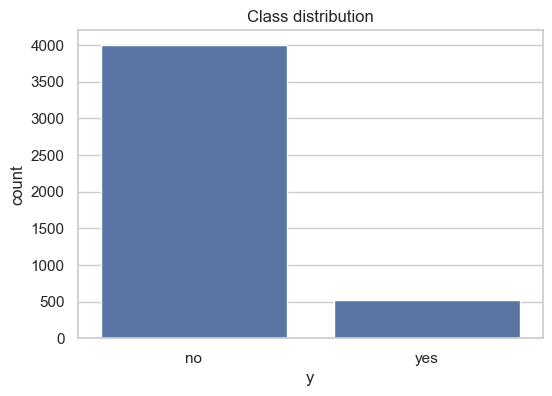

In [6]:
print("--- Target Variable ('y') Analysis ---")
target_column = "y"

# 1. Get counts for each class
class_counts: pd.Series = (
    None  # This doesn't have to be a Series, there are multiple ways to do this
)
### STUDENT CODE HERE (0.5 pt)
class_counts = bank_df.loc[:,target_column].value_counts()
display(class_counts)
### STUDENT CODE until HERE

# 2. Calculate percentages
total_samples: int = len(bank_df)
percentage_no: float = 0.0
percentage_yes: float = 0.0
### STUDENT CODE HERE (0.5 pt)
percentage_no = class_counts[0]/total_samples*100
percentage_yes = class_counts[1]/total_samples*100

### STUDENT CODE until HERE
print(f"\nPercentage of Class 'no': {percentage_no:.2f}%")
print(f"Percentage of Class 'yes': {percentage_yes:.2f}%")

# 3. Visualize the class distribution. Make sure it's a well-labeled bar plot (Use a title, x/y labels, etc.)
# Consider using `seaborn.countplot()` or a similar function from matplotlib
plt.figure(figsize=(6, 4))
### STUDENT CODE HERE (0.5 pt)
sns.countplot(x=target_column, data=bank_df)
plt.title("Class distribution")
### STUDENT CODE until HERE
plt.show()

<div class="alert alert-block alert-success">
<b>Question 1.1: Class Imbalance (0.5 pts)</b>
<ol>
    <li> Based on the counts and percentages calculated above, would you say the dataset is balanced or imbalanced with respect to the target variable 'y'? Why is this important to know?</li>
</ol>
</div>

<div class="alert alert-block alert-info">
<b>Further Reading on Class Imbalance Issues:</b>
<ul>
    <li><b>Blog Post:</b> A good overview of the problem and common techniques: <a href="https://ydata.ai/resources/a-comprehensive-guide-to-tackle-imbalanced-data-for-machine-learning#:~:text=Imbalanced%20data%20occurs%20when%20the,within%20a%20dataset%20is%20unequal." target="_blank">What is imbalanced data in Machine Learning? - YData Blog (2023)</a> or <a href="https://blog.roboflow.com/handling-unbalanced-classes/" target="_blank">5 Strategies for Handling Unbalanced Classes in Machine Learning - Roboflow Blog (2025)</a></li>
    <li><b>Paper/Review:</b> For a more in-depth academic perspective: <a href="https://www.researchgate.net/publication/301596547_Learning_from_imbalanced_data_Open_challenges_and_future_directions" target="_blank">Learning from imbalanced data: Open challenges and future directions (Review Paper, 2016)</a> or search for recent survey papers on "class imbalance learning".</li>
</ul>
These resources explain why standard models might perform poorly on the minority class and discuss common strategies to mitigate this.
</div>


<div class="alert alert-block alert-success">
<b>Your Answer:</b>
<ol>
    <li>Das Datenset ist imbalanced, da die Class distribution ungefähr 88% zu 12% beträgt. Es ist wichtig, diese Verteilung zu kennen, da das Modell sonst ungenau und unzuverlässig wird, weil das Modell die majority class bevorzugt, da diese am präsentesten im Training ist.    </li> 
</ol>
</div>

## 1.5 Correlation Analysis



Correlation analysis helps us understand the linear relationships between **numerical** features. We typically calculate the **Pearson correlation coefficient**, which ranges from -1 (perfect negative linear correlation) to +1 (perfect positive linear correlation), with 0 indicating no linear correlation. It essentially measures how well the relationship between two variables can be described by a straight line. You can find a more detailed classification of different degrees of correlation here: <a href="https://www.statisticssolutions.com/free-resources/directory-of-statistical-analyses/pearsons-correlation-coefficient/" target="_blank">Pearson's Correlation Coefficient Overview</a> or generally <a href="https://en.wikipedia.org/wiki/Pearson_correlation_coefficient" target="_blank">Wikipedia: Pearson correlation coefficient</a>.

Visualizing the correlation matrix as a **heatmap** makes it easier to spot potentially strong relationships between features, or between features and the (numerically encoded) target. Usually the colour red is used to highlight strong correlation.


<div class="alert alert-block alert-info">
    <b>Note:</b> We'll look at numerical features only for now using Pearson correlation. Analysing relationships involving <b>categorical</b> features often requires different techniques. For two categorical variables, one might use a <b>Chi-Squared Test of Independence</b> (<a href="https://www.scribbr.com/statistics/chi-square-tests/" target="_blank">Scribbr explanation</a>) along with measures like Cramer's V to assess association strength. For a numerical and a categorical variable, techniques like <b>ANOVA</b> (Analysis of Variance) or visual comparisons (e.g., box plots per category) are common.
</div>

<div class="alert alert-block alert-success">
<b>Task 1.5: Correlation Matrix and Heatmap (1.5 pts)</b>

<ul>
    <li> Calculate the pairwise correlation matrix for the numerical features in <i>bank_df</i>.</li>
    <li> Visualize this matrix as a heatmap using seaborn. Ensure annotations are included and the colormap is suitable (e.g., <i>coolwarm</i> for diverging values).</li>
</ul>
</div>


--- Correlation Analysis (Numerical Features) ---

Correlation matrix (Numerical Features):


,age,balance,day,duration,campaign,pdays,previous
age,1.00,0.08,-0.02,-0.00,-0.01,-0.01,-0.00
balance,0.08,1.00,-0.01,-0.02,-0.01,0.01,0.03
day,-0.02,-0.01,1.00,-0.02,0.16,-0.09,-0.06
duration,-0.00,-0.02,-0.02,1.00,-0.07,0.01,0.02
campaign,-0.01,-0.01,0.16,-0.07,1.00,-0.09,-0.07
pdays,-0.01,0.01,-0.09,0.01,-0.09,1.00,0.58
previous,-0.00,0.03,-0.06,0.02,-0.07,0.58,1.00



 Heatmap:


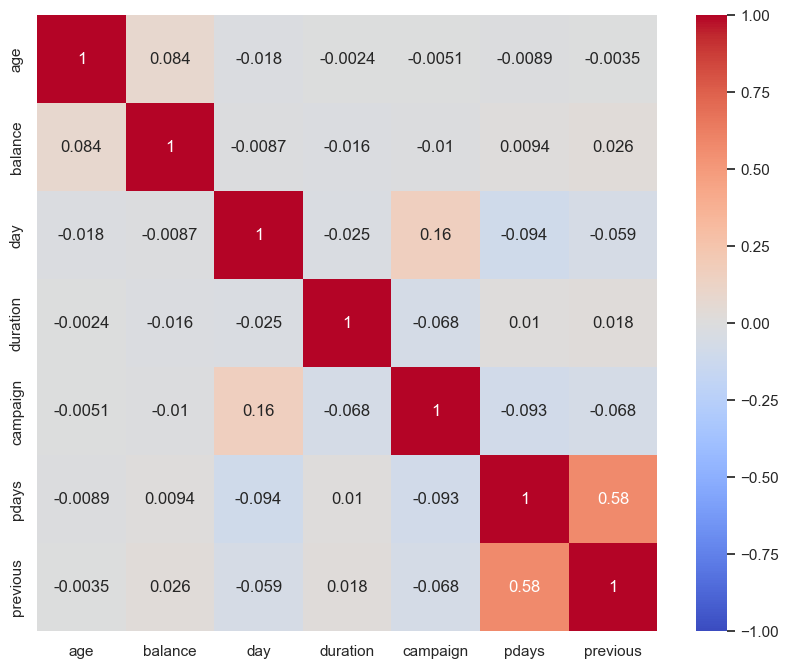

In [7]:
print("\n--- Correlation Analysis (Numerical Features) ---")

# Calculate the correlation matrix for numerical columns only
# Make sure to consider only numerical features. Pandas has built-in functions which can attain the correlation matrix.
correlation_matrix: pd.DataFrame = None
### STUDENT CODE HERE (0.5 pt)
correlation_matrix = bank_df.corr(method='pearson', numeric_only = True)
### STUDENT CODE until HERE

if correlation_matrix is not None:
    print("\nCorrelation matrix (Numerical Features):")
    display(correlation_matrix)

    # Visualize the correlation matrix as a heatmap
    print("\n Heatmap:")
    plt.figure(figsize=(10, 8))
    ### STUDENT CODE HERE (1 pt)
    sns.heatmap(correlation_matrix, vmin=-1, vmax=1,xticklabels='auto',yticklabels='auto',annot=True,cmap='coolwarm')

    ### STUDENT CODE until HERE
    plt.show()
else:
    print("Could not calculate correlation matrix.")

<div class="alert alert-block alert-success">
<b>Question 1.2: Interpreting Correlations (1 pt)</b>
<ol>
    <li> Looking at the heatmap, are there any pairs of numerical features that show a strong positive or negative correlation (e.g., magnitude > 0.5 or < -0.5)?</li>
    <li> Pay special attention to the <i>duration</i> column. Does it show a notable correlation with any other numerical feature? What about its potential relationship with the <b>target</b> variable <i>y</i> (even though <i>y</i> isn't numerical here, high duration might intuitively relate to subscription)? Why might <i>duration</i> be problematic for prediction, as mentioned earlier?</li>
</ol>
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b>
<ol>
    <li>Ein größerer Zusammenhang mit einem Korrelationswert von 0,58 besteht zwischen den Variablen pdays und previous.</li>
    <li></li>
</ol>
</div>

## 1.6 Initial Distribution Visualization

Visualising the distribution of individual features helps us understand their shape (e.g., symmetric, skewed), range, and potential presence of outliers or multiple modes.

- **Histograms** or **Density Plots (KDE)** are suitable for numerical features.
- **Count Plots** are suitable for categorical features.

<div class="alert alert-block alert-info">
    <b>Note:</b> If skewness is something new to you, below you can find a brief explanation.
</div>

**Understanding Skewness**

When looking at numerical distributions, pay attention to **skewness**, which measures the asymmetry of the distribution:
*   **Symmetric (Zero Skewness):** The distribution looks like a mirror image around its center (like a perfect bell curve/normal distribution). The mean, median, and mode are typically close together.
*   **Right-Skewed (Positive Skewness):** The tail on the right side of the distribution is longer or fatter. This means there are some unusually high values pulling the mean to the right, making the mean generally greater than the median. Examples include income or house prices.
*   **Left-Skewed (Negative Skewness):** The tail on the left side is longer. There are some unusually low values pulling the mean to the left, making the mean generally less than the median. Examples might include test scores where many students do well.

Is skewness good or bad? It's neither inherently good nor bad, but it's important to recognise:
*   **Impact on Models:** Highly skewed data can sometimes violate assumptions of certain statistical models (especially those assuming normality, like linear regression) or disproportionately influence models sensitive to outliers (like distance-based algorithms).
*   **Potential for Transformation:** If skewness is problematic for a chosen model, transformations (like logarithmic, square root, or Box-Cox) can sometimes be applied to make the distribution more symmetric.
*   **Insight:** Skewness tells you about the nature of your data – are extreme values common on one side?

<div class="alert alert-block alert-success">
<b>Task 1.6: Feature Distribution Plots (2 pts)</b>

<ul>
    <li> Select a few key numerical features (e.g., 'age', 'balance') and plot their distributions using histograms or density plots.</li>
    <li> Select a few key categorical features (e.g., 'job', 'marital', 'education') and plot their distributions using count plots.</li>
    <li> Ensure plots have appropriate titles and labels.</li>
    <li><i>Hint: To arrange multiple plots neatly, you can create a grid of subplots using Matplotlib's <code>plt.subplots()</code> or <code>plt.figure()</code> with <code>add_subplot()</code>, or explore Seaborn's FacetGrid for more complex layouts linked to data subsets. See <a href="https://matplotlib.org/stable/users/explain/axes/arranging_axes.html" target="_blank">Matplotlib subplot guide</a> or <a href="https://seaborn.pydata.org/tutorial/axis_grids.html" target="_blank">Seaborn figure grids guide</a>.</i></li>
</ul>
</div>


--- Initial Distribution Visualization ---

Plotting distributions for: ['age', 'balance']


<Figure size 1200x1000 with 0 Axes>

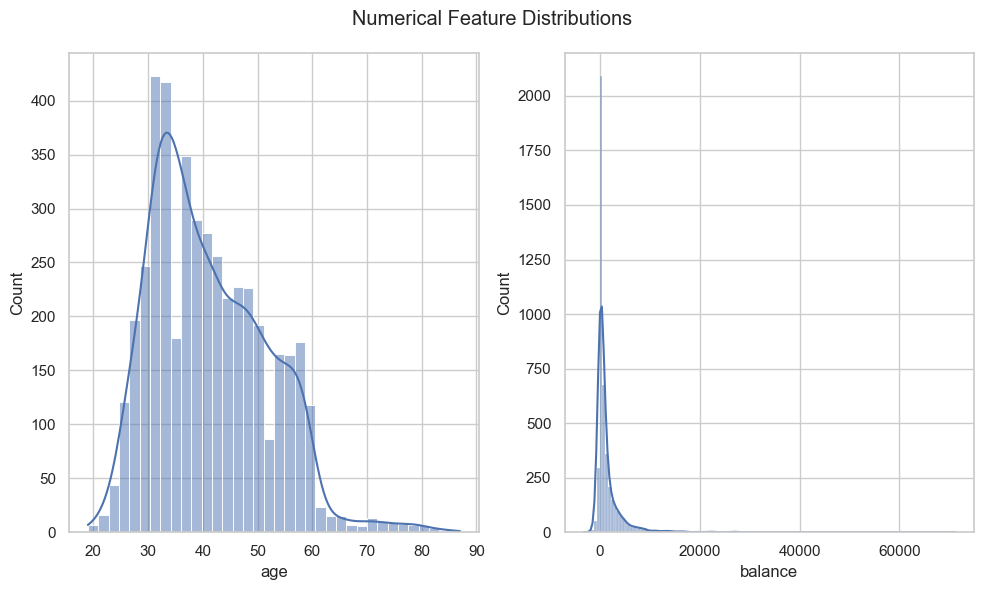


Plotting distributions for: ['job', 'marital', 'education']


<Figure size 1000x1500 with 0 Axes>

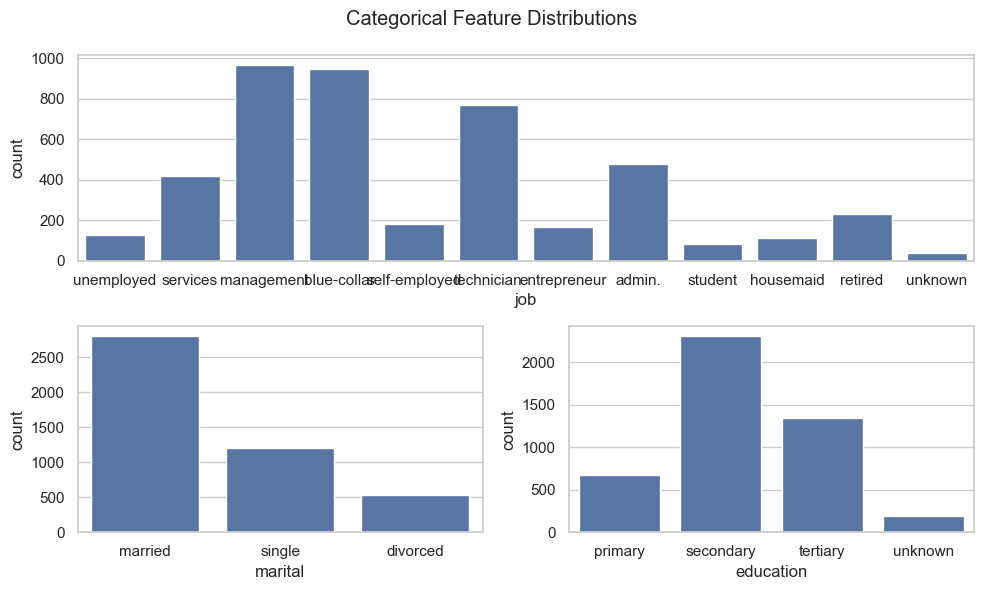

In [8]:
print("\n--- Initial Distribution Visualization ---")

# 1. Numerical Feature Distributions
numerical_features_to_plot: List[str] = [
    "age",
    "balance",
]  # You can add more features if desired
print(f"\nPlotting distributions for: {numerical_features_to_plot}")

plt.figure(
    figsize=(12, 5 * len(numerical_features_to_plot))
)
### STUDENT CODE HERE (1 pt)
fig, axs = plt.subplots(1,2)
sns.histplot(data=bank_df,x=numerical_features_to_plot[0],kde=True,ax=axs[0])

sns.histplot(data=bank_df,x=numerical_features_to_plot[1],kde=True,ax=axs[1])
fig.suptitle("Numerical Feature Distributions")
### STUDENT CODE until HERE
plt.tight_layout()
plt.show()


# 2. Categorical Feature Distributions
categorical_features_to_plot: List[str] = [
    "job",
    "marital",
    "education",
]  # Add more if desired
print(f"\nPlotting distributions for: {categorical_features_to_plot}")

plt.figure(
    figsize=(10, 5 * len(categorical_features_to_plot))
)
### STUDENT CODE HERE (1 pt)
fig =plt.figure()
spec = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(spec[0, :])
sns.countplot(x=categorical_features_to_plot[0],data=bank_df,ax=ax0)

ax10 = fig.add_subplot(spec[1, 0])
sns.countplot(x=categorical_features_to_plot[1],data=bank_df,ax=ax10)

ax11 = fig.add_subplot(spec[1, 1])
sns.countplot(x=categorical_features_to_plot[2],data=bank_df,ax=ax11)

fig.suptitle("Categorical Feature Distributions")
### STUDENT CODE until HERE
plt.tight_layout()
plt.show()

## Unit 1 Summary & Deep Dive

In this unit, we loaded the Bank Marketing dataset using Fireducks and performed essential Exploratory Data Analysis (EDA). We examined the data's structure, types, and basic statistics. We identified the target variable ('y'), noted the significant class imbalance, explored correlations among numerical features (highlighting the problematic 'duration' feature), and visualized the distributions of key features.

This initial exploration provides a foundation for the next steps: cleaning the data, engineering features, and preparing it for model training.

### Deep Dive: Fireducks Speed & Compatibility

Fireducks aims to provide a familiar Pandas API while potentially leveraging different backend execution engines (like Dask or Ray) for optimization, especially on larger datasets or in distributed environments. Let's do a quick comparison for loading our small `bank.csv` dataset.

*Note: On small, local datasets, the overhead of initializing optimized backends might negate or even reverse speed advantages. The true benefits are typically seen at scale or with computationally intensive operations that can be parallelized.*

In [9]:
import time
import pandas as pd_original  # Import standard pandas
import fireducks.pandas as pd_fireducks  # Import 
filename = "data/bank-full.csv"

# --- Time loading and filtering with standard Pandas ---
print("--- Standard Pandas ---")
start_time_pd_load = time.time()
try:
    df_pd = pd_original.read_csv(filename, sep=';')
    load_time_pd = time.time() - start_time_pd_load
    print(f"Load Time: {load_time_pd:.6f} seconds")

    # Time a filtering operation
    start_time_pd_filter = time.time()
    # Example Filter: balance > 1000 AND job contains 'manage'
    filtered_pd = df_pd[(df_pd["balance"] > 1000) & (
        df_pd["job"].str.contains("manage"))]
    filter_time_pd = time.time() - start_time_pd_filter
    print(f"Filter Time: {filter_time_pd:.6f} seconds")
    print(f"Filtered count: {len(filtered_pd)}")
    total_time_pd = time.time() - start_time_pd_load
    print(f"Total time (Pandas): {total_time_pd:.6f} seconds")

except Exception as e:
    print(f"Error loading/processing with standard Pandas: {e}")
    load_time_pd = -1
    filter_time_pd = -1

print("-" * 25)

# --- Time loading and filtering with Fireducks Pandas ---
print("--- Fireducks Pandas ---")
start_time_fd_load = time.time()
try:
    # Note: Ensure Fireducks is configured if using specific backends like DuckDB explicitly.
    # By default, it might use standard pandas or a simple local backend.
    df_fd = pd_fireducks.read_csv(filename, sep=';')
    load_time_fd = time.time() - start_time_fd_load
    print(f"Load Time: {load_time_fd:.6f} seconds")

    # Time the same filtering operation
    start_time_fd_filter = time.time()
    # Example Filter: balance > 1000 AND job contains 'manage'
    filtered_fd = df_fd[(df_fd["balance"] > 1000) & (
        df_fd["job"].str.contains("manage"))]
    # Force computation if Fireducks uses lazy evaluation (might not be needed for simple ops)
    # filtered_fd_len = len(filtered_fd) # Accessing length might trigger computation
    filter_time_fd = time.time() - start_time_fd_filter
    print(f"Filter Time: {filter_time_fd:.6f} seconds")
    # Use len() to ensure result is computed
    print(f"Filtered count: {len(filtered_fd)}")
    total_time_fd = time.time() - start_time_fd_load
    print(f"Total time (Fireducks): {total_time_fd:.6f} seconds")

except Exception as e:
    print(f"Error loading/processing with Fireducks Pandas: {e}")
    load_time_fd = -1
    filter_time_fd = -1

# --- Comparison ---
print("-" * 25)
if load_time_pd > 0 and load_time_fd > 0:
    if total_time_fd < total_time_pd:
        print(
            f"Fireducks was potentially faster overall (by {total_time_pd - total_time_fd:.6f}s).")
        if filter_time_fd < filter_time_pd:
            print(
                f"  - Filtering step was faster (by {filter_time_pd - filter_time_fd:.6f}s).")
        elif filter_time_pd < filter_time_fd:
            print(
                f"  - Filtering step was slower (by {filter_time_fd - filter_time_pd:.6f}s).")
    else:
        print(
            f"Standard Pandas was faster or equal overall (by {total_time_fd - total_time_pd:.6f}s).")
        if filter_time_fd < filter_time_pd:
            print(
                f"  - Filtering step was faster (by {filter_time_pd - filter_time_fd:.6f}s).")
        elif filter_time_pd < filter_time_fd:
            print(
                f"  - Filtering step was slower (by {filter_time_fd - filter_time_pd:.6f}s).")
    print("(Remember, differences on small local data may not reflect large-scale performance or specific backend optimizations.)")

print("\nAPI Compatibility: Notice that the code for loading and filtering is identical, highlighting Fireducks' compatibility with the Pandas API.")

# Clean up DataFrames if needed
del df_pd
del df_fd
del filtered_pd
del filtered_fd

ModuleNotFoundError: No module named 'fireducks'

**Why can Fireducks be faster?**

*   **Parallelism:** For operations that can be broken down (like applying a function row-wise or certain group-bys), Fireducks can potentially distribute the work across multiple CPU cores or even multiple machines (if using backends like Dask or Ray). Standard Pandas primarily runs on a single core.
*   **Optimized Backends:** Depending on the configured backend, operations might be translated into more optimized code or execution plans than standard Pandas' NumPy-based backend for certain tasks.
*   **Memory Management:** For datasets larger than RAM, libraries like Dask (which Fireducks can use) can perform computations out-of-core, whereas standard Pandas requires the entire DataFrame to fit in memory.

Again, these benefits are most pronounced at scale. The key takeaway for this course is the **API compatibility**, allowing you to write familiar Pandas code.

### Quick Note on pandas, and further database-like libraries

There are actually multiple open-source libraries focusing on the management one data, an example for one of which addresses performance issues incurring with large dataframes is **[RAPID's cuDF](https://docs.rapids.ai/api/cudf/stable/)**. The only drawback is that it requires a CUDA-capable GPU. It makes fireducks look slow.

<p align='center'>
    <img src="https://docs.rapids.ai/api/cudf/stable/_images/duckdb-benchmark-groupby-join.png" width=60% height="auto"/>
    <br>
    <em> Figure 1: Results of the <a href="https://duckdblabs.github.io/db-benchmark/" target="_blank">Database-like ops benchmark</a> including cudf.pandas. </em>
</p>

### Deep Dive: Correlation vs. Causation in Machine Learning

In our EDA, we looked at the correlation matrix. It's tempting to interpret strong correlations as one feature *causing* another, or a feature *causing* a change in the target variable. However, this is a dangerous fallacy. **Correlation does not imply causation.**

**What is Correlation?**
Correlation measures the statistical relationship or association between two variables. It tells us how much they tend to move together.
*   *Positive Correlation:* When one variable increases, the other tends to increase (e.g., height and weight).
*   *Negative Correlation:* When one variable increases, the other tends to decrease (e.g., price and demand).
*   *Zero Correlation:* No linear relationship exists.

**What is Causation?**
Causation means that a change in one variable directly *produces* or *leads to* a change in another variable. There's a mechanism linking the two.

**Why the Difference Matters in ML:**

1.  **Feature Importance vs. Causal Impact:** Many ML models can provide "feature importance" scores (e.g., coefficients in linear models, Gini importance in tree models). These scores often reflect how *useful* a feature is for *predicting* the target *within the context of the model and the specific dataset*. This usefulness is often driven by correlation. However, it **does not** automatically mean that changing this feature will *cause* the target to change in the real world.
    *   *Example:* In the bank data, 'duration' is highly predictive (high feature importance) because it's strongly correlated with 'y'. But calling someone for longer doesn't *cause* them to subscribe (the interest likely causes both the longer call *and* the subscription). Acting on this feature importance by simply telling call center agents to talk longer wouldn't necessarily increase subscriptions.

2.  **Confounding Variables:** An observed correlation between feature A and target B might be entirely due to a third, unobserved variable C (a confounder) that influences both A and B.
    *   *Example:* Ice cream sales and crime rates are positively correlated. Does eating ice cream cause crime? No. The confounder is hot weather (variable C), which causes people to buy more ice cream (A) and also causes more people to be outdoors, leading to more opportunities for crime (B). A model might find ice cream sales predictive of crime, but intervening based on this (e.g., banning ice cream) would have no causal effect on crime rates.

3.  **Spurious Correlations:** Sometimes, correlations appear purely by chance in the data, especially with many features, without any underlying connection. Models might pick up on these spurious correlations, leading to overfitting and poor generalization.

4.  **Actionable Insights:** If the goal of building an ML model is not just prediction but also to understand *how to influence the outcome* (e.g., how to *increase* bank subscriptions), relying solely on correlational feature importance is insufficient and potentially misleading. Determining causal factors requires different techniques, often involving experimental design (like A/B testing) or specialized causal inference methods (e.g., using causal graphs, instrumental variables, regression discontinuity).

**In Summary for ML Practitioners:**
*   Use correlation analysis and feature importance to understand which features are *associated* with the target and are *predictive* within your model.
*   Be extremely cautious about interpreting these associations as causal relationships.
*   Validate potential causal hypotheses through controlled experiments (if possible) or use appropriate causal inference techniques if your goal is intervention rather than just prediction.
*   Always consider potential confounding variables and the context of the data collection process.